# PROJECT SAINS DATA

#Analisis Kualitas Udara dan Distribusi Polutan di Kecamatan Labang, Bangkalan Menggunakan Data Satelit Copernicus

##Laporan Observasi Spasial dan Temporal (Periode Agustus 2025 – Agustus 2026)

##Latar Belakang Proyek

Kecamatan Labang, sebagai titik akses utama Jembatan Suramadu, memiliki tingkat mobilitas kendaraan dan aktivitas antropogenik yang padat. Kondisi geografis dan infrastruktur ini berpotensi memberikan dampak signifikan terhadap fluktuasi kualitas udara di wilayah tersebut. Proyek ini bertujuan untuk melakukan pemantauan dan analisis kualitas udara secara komprehensif menggunakan instrumen satelit Sentinel-5P dari Copernicus Data Space Ecosystem.

Melalui pendekatan sains data, proyek ini mengekstraksi, memproses, dan memvisualisasikan data enam polutan utama (NO2, CO,SO2, dan O3) selama satu tahun terakhir. Hasil dari analisis ini divisualisasikan ke dalam dashboard statis interaktif guna memberikan wawasan (insight) yang informatif mengenai tren tingkat pencemaran udara kepada masyarakat dan akademisi.

#Business Understanding

##Mengamati Kualitas Udara

Indeks Kualitas Udara (AQI) adalah angka pengukur standar yang digunakan untuk menilai seberapa bersih atau tercemarnya udara di suatu wilayah. Angka ini berfungsi sebagai indikator untuk mengetahui dampak kualitas udara terhadap kesehatan manusia. Semakin tinggi nilai indeksnya, semakin buruk kualitas udaranya.

##Unsur-Unsur Polutan Penyebab Kualitas Udara

Baik atau buruknya kualitas udara sangat dipengaruhi oleh tingkat konsentrasi gas dan partikel berbahaya (polutan) di atmosfer. Dalam pengamatan ini, unsur polutan utama yang diamati meliputi: NO₂, CO, SO₂, O₃



#Tujuan dan Ruang Lingkup Analisis

Fase Business Understanding ini bertujuan untuk menerjemahkan permasalahan lingkungan nyata ke dalam kerangka kerja analitik berbasis data satelit. Melalui pemanfaatan data penginderaan jauh (remote sensing) dari platform Copernicus Sentinel-5P, analisis ini dirancang untuk:

1. Menggambarkan tren fluktuasi historis konsentrasi polutan dari waktu ke waktu (analisis temporal).

2. Memetakan sebaran wilayah secara spasial melalui indikator gradasi warna zona kualitas udara (dari kategori baik/hijau hingga buruk/merah).

3. Memberikan informasi valid yang dapat dijadikan acuan mitigasi lingkungan atau pengambilan kebijakan di wilayah studi.

#Data Understanding

##Pengumpulan Data

Data polusi udara diakuisisi (crawling) dari satelit Sentinel-5P melalui Copernicus Data Space Ecosystem dalam format NetCDF (.nc) yang memuat informasi konsentrasi gas atmosfer secara spasial.

##Eksplorasi Data

Visualisasi Spasial (Peta): Memetakan sebaran geografis polusi secara interaktif menggunakan library Folium.

Visualisasi Temporal (Grafik): Mengekstrak data ke format CSV untuk memvisualisasikan tren harian melalui grafik time-series.

Pengecekan Kualitas Data: Mengidentifikasi data kosong (missing values) akibat tutupan awan (cloud cover) serta anomali (outliers/noises) dari galat sensor satelit.

##Rincian Pengambilan Data:

Pengambilan data difokuskan khusus menggunakan titik koordinat (bounding box) Kecamatan Labang, Kabupaten Bangkalan. Data ditarik berurutan setiap hari dengan rentang waktu observasi selama satu tahun penuh, yaitu dari tanggal 24 Agustus 2025 s.d. 24 Agustus 2026.

#Penentuan Area of Interest (AOI) dan Batas Spasial Wilayah Studi

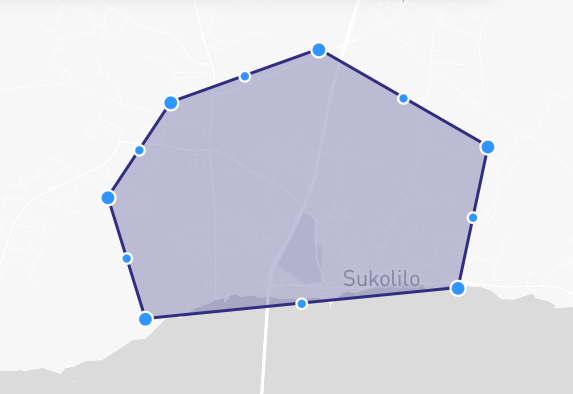

Tahap Data Understanding ini dilakukan dengan mendefinisikan cakupan wilayah geografis (Area of Interest/AOI) studi kasus di Kecamatan Labang, Kabupaten Bangkalan. Batas wilayah direpresentasikan menggunakan format GeoJSON berupa poligon tertutup (polygon coordinates) yang terdiri dari serangkaian titik koordinat lintang dan bujur (latitude dan longitude).

Pemanfaatan format GeoJSON ini berfungsi sebagai batasan spasial presisi (bounding box dan geometri area) saat melakukan ekstraksi data dari platform pengolahan citra satelit Sentinel-5P. Dengan mendefinisikan AOI secara spesifik, data polutan yang ditarik dari server hanya mencakup wilayah administratif Kecamatan Labang dan menghindari bias dari area di luar zona penelitian.

In [1]:
!pip install openeo

  Using cached openeo-0.51.0-py3-none-any.whl.metadata (8.9 kB)
  Using cached geopandas-1.0.1-py3-none-any.whl.metadata (2.2 kB)
Using cached openeo-0.51.0-py3-none-any.whl (349 kB)
Using cached geopandas-1.0.1-py3-none-any.whl (323 kB)

   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   ---------------------------------------- 0/2 [geopandas]
   --------------------------------------

In [2]:
import openeo
import xarray as xr
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

# 2. DEFINISI WILAYAH (AOI LABANG, BANGKALAN)

aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"id": "labang_bangkalan"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [112.7678321, -7.1316747],
                        [112.7893293, -7.124042],
                        [112.8138634, -7.138044],
                        [112.8095339, -7.1584098],
                        [112.7641537, -7.1628647],
                        [112.7587017, -7.1453631],
                        [112.7678321, -7.1316747]
                    ]
                ],
            },
        }
    ],
}

batas_spasial = {
    "west": 112.7587017,
    "south": -7.1628647,
    "east": 112.8138634,
    "north": -7.124042
}

Authenticated using refresh token.


In [ ]:
print("Memulai batch job untuk NO2...")
s5_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-24", "2026-08-24"],
    spatial_extent=batas_spasial,
    bands=["NO2"],
    properties={"s5p:timeliness": lambda t: t == "OFFL"}
)
s5_no2 = s5_no2.aggregate_temporal_period(reducer="mean", period="day")
s5_no2 = s5_no2.aggregate_spatial(reducer="mean", geometries=aoi)
job_no2 = s5_no2.execute_batch(title="NO2 Labang", outputfile="polutan_no2.nc")
print("Job NO2 selesai!")

print("Memulai batch job untuk CO...")
s5_co = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-24", "2026-08-24"],
    spatial_extent=batas_spasial,
    bands=["CO"],
    properties={"s5p:timeliness": lambda t: t == "OFFL"}
)
s5_co = s5_co.aggregate_temporal_period(reducer="mean", period="day")
s5_co = s5_co.aggregate_spatial(reducer="mean", geometries=aoi)
job_co = s5_co.execute_batch(title="CO Labang", outputfile="polutan_co.nc")
print("Job CO selesai!")

Memulai batch job untuk NO2...
0:00:00 Job 'j-26082815310643cd980239bfc393d0b5': send 'start'
0:00:03 Job 'j-26082815310643cd980239bfc393d0b5': queued (progress 0%)
0:00:08 Job 'j-26082815310643cd980239bfc393d0b5': queued (progress 0%)
0:00:15 Job 'j-26082815310643cd980239bfc393d0b5': queued (progress 0%)
0:00:23 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:00:33 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:00:45 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:01:01 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:01:20 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:01:44 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:02:14 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:02:51 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:03:38 Job 'j-26082815310643cd980239bfc393d0b5': running (progress N/A)
0:04:37 Job 'j-26082815310643cd98023

In [ ]:
polutan_sisa = ["SO2", "O3"]

for pol in polutan_sisa:
    print(f"Memulai batch job untuk {pol}...")
    s5_data = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2025-08-24", "2026-08-24"],
        spatial_extent=batas_spasial,
        bands=[pol],
        properties={"s5p:timeliness": lambda t: t == "OFFL"}
    )
    s5_data = s5_data.aggregate_temporal_period(reducer="mean", period="day")
    s5_data = s5_data.aggregate_spatial(reducer="mean", geometries=aoi)

    job = s5_data.execute_batch(title=f"{pol} Labang", outputfile=f"polutan_{pol.lower()}.nc")
    print(f"Job {pol} selesai dan tersimpan sebagai polutan_{pol.lower()}.nc!")

Memulai batch job untuk SO2...
0:00:00 Job 'j-2608281543454e7881ac20a39a3e7834': send 'start'
0:00:03 Job 'j-2608281543454e7881ac20a39a3e7834': created (progress 0%)
0:00:08 Job 'j-2608281543454e7881ac20a39a3e7834': queued (progress 0%)
0:00:14 Job 'j-2608281543454e7881ac20a39a3e7834': queued (progress 0%)
0:00:23 Job 'j-2608281543454e7881ac20a39a3e7834': queued (progress 0%)
0:00:33 Job 'j-2608281543454e7881ac20a39a3e7834': queued (progress 0%)
0:00:45 Job 'j-2608281543454e7881ac20a39a3e7834': running (progress N/A)
0:01:00 Job 'j-2608281543454e7881ac20a39a3e7834': running (progress N/A)
0:01:20 Job 'j-2608281543454e7881ac20a39a3e7834': running (progress N/A)
0:01:44 Job 'j-2608281543454e7881ac20a39a3e7834': running (progress N/A)
0:02:14 Job 'j-2608281543454e7881ac20a39a3e7834': running (progress N/A)
0:02:52 Job 'j-2608281543454e7881ac20a39a3e7834': running (progress N/A)
0:03:39 Job 'j-2608281543454e7881ac20a39a3e7834': finished (progress 100%)
Job SO2 selesai dan tersimpan sebagai

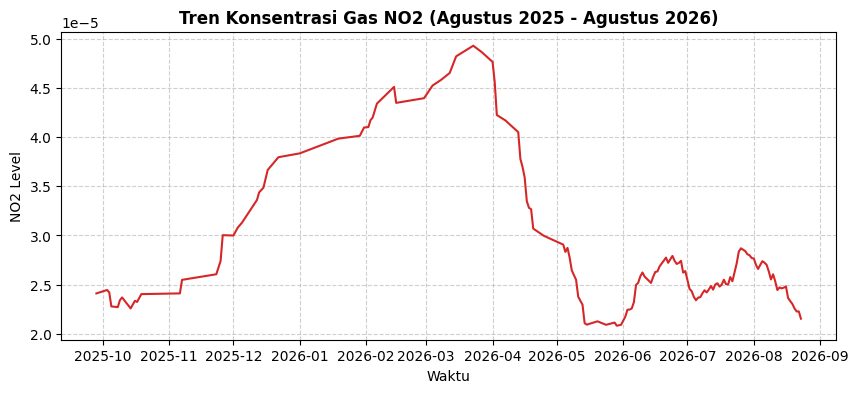

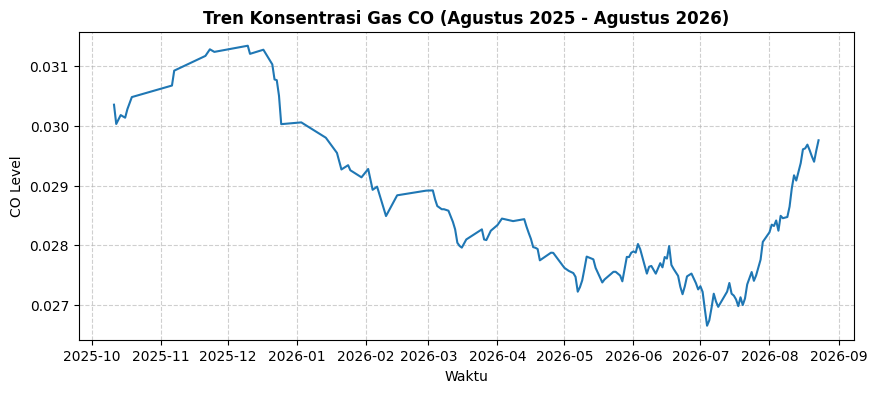

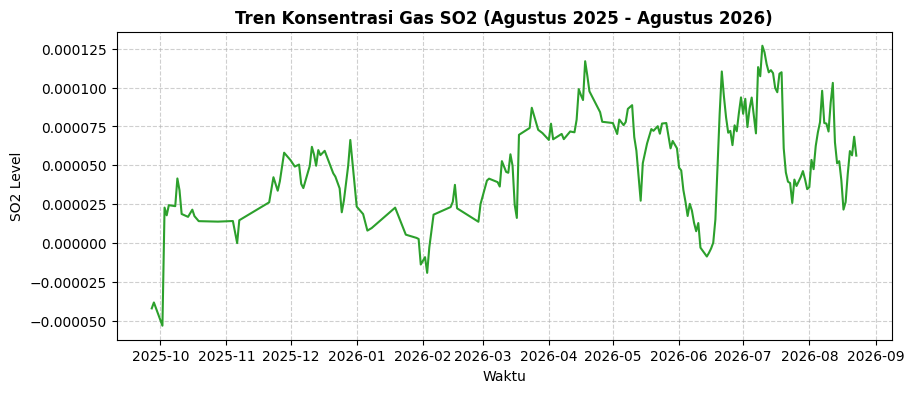

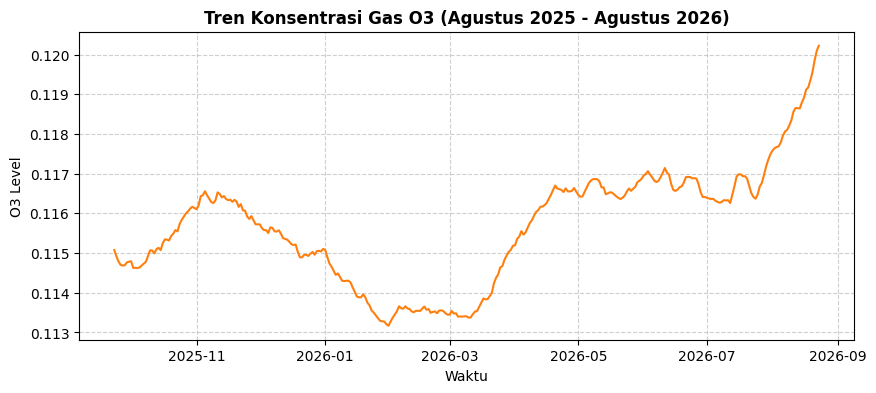

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# Memuat semua dataset
ds_no2 = xr.load_dataset("polutan_no2.nc").rolling(t=30).mean()
ds_co = xr.load_dataset("polutan_co.nc").rolling(t=30).mean()
ds_so2 = xr.load_dataset("polutan_so2.nc").rolling(t=30).mean()
ds_o3 = xr.load_dataset("polutan_o3.nc").rolling(t=30).mean()

# --- Grafik 1: NO2 ---
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(ds_no2.t, ds_no2.NO2.to_numpy().flatten(), color='tab:red')
plt.title("Tren Konsentrasi Gas NO2 (Agustus 2025 - Agustus 2026)", fontweight="bold")
plt.xlabel("Waktu")
plt.ylabel("NO2 Level")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Grafik 2: CO ---
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(ds_co.t, ds_co.CO.to_numpy().flatten(), color='tab:blue')
plt.title("Tren Konsentrasi Gas CO (Agustus 2025 - Agustus 2026)", fontweight="bold")
plt.xlabel("Waktu")
plt.ylabel("CO Level")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Grafik 3: SO2 ---
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(ds_so2.t, ds_so2.SO2.to_numpy().flatten(), color='tab:green')
plt.title("Tren Konsentrasi Gas SO2 (Agustus 2025 - Agustus 2026)", fontweight="bold")
plt.xlabel("Waktu")
plt.ylabel("SO2 Level")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# --- Grafik 4: O3 ---
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(ds_o3.t, ds_o3.O3.to_numpy().flatten(), color='tab:orange')
plt.title("Tren Konsentrasi Gas O3 (Agustus 2025 - Agustus 2026)", fontweight="bold")
plt.xlabel("Waktu")
plt.ylabel("O3 Level")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()